#### Imports

In [1]:
import qutip as qt
import scqubits as scq
import numpy as np
import matplotlib.pyplot as plt

#### Parameters

In [ ]:
system_params = {}

#### Fully Quantum

In [2]:
# truncated dimension of the transmon and the resonator
N_tmon, N_res = 10, 50

tmon = scq.Transmon(
    EJ = 20,
    EC = 0.3,
    ng = 0.25,
    ncut = 100,
    truncated_dim = N_tmon,
)

res = scq.Oscillator(
    E_osc = 5,
    l_osc = 1,
    truncated_dim = N_res,
)

hilbertspace = scq.HilbertSpace([tmon, res])

hilbertspace.add_interaction(
    g = 0.1,
    op1 = tmon.n_operator,
    op2 = res.n_operator
)

 /Users/thomasverrill/PycharmProjects/ECE559/.venv/lib/python3.12/site-packages/scqubits/utils/spectrum_utils.py: 199RuntimeWarning: overflow encountered in matmul
 /Users/thomasverrill/PycharmProjects/ECE559/.venv/lib/python3.12/site-packages/scqubits/utils/spectrum_utils.py: 199RuntimeWarning: invalid value encountered in matmul
 /Users/thomasverrill/PycharmProjects/ECE559/.venv/lib/python3.12/site-packages/scqubits/utils/spectrum_utils.py: 199

In [7]:
hilbertspace.generate_lookup(
    ordering = 'LX'
)
hilbertspace.generate_lookup(
    ordering = 'LX',
    subsys_priority = [1, 0]
)

hilbertspace.bare_index(8)

(2, 1)

 /Users/thomasverrill/PycharmProjects/ECE559/.venv/lib/python3.12/site-packages/scqubits/utils/spectrum_utils.py: 199RuntimeWarning: overflow encountered in matmul
 /Users/thomasverrill/PycharmProjects/ECE559/.venv/lib/python3.12/site-packages/scqubits/utils/spectrum_utils.py: 199RuntimeWarning: invalid value encountered in matmul
 /Users/thomasverrill/PycharmProjects/ECE559/.venv/lib/python3.12/site-packages/scqubits/utils/spectrum_utils.py: 199

5


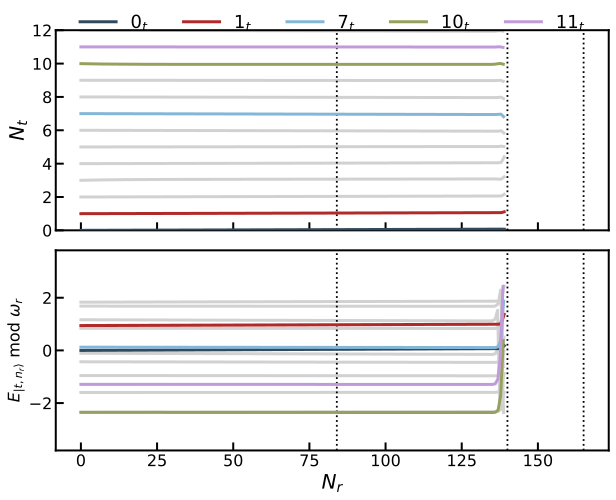

In [21]:
import scqubits as scq
import numpy as np
import matplotlib.pyplot as plt

Nt, Nr = 14, 140
tmon = scq.Transmon(EJ=2.5, EC=0.05, ng=0.25, ncut=100, truncated_dim=Nt)
res  = scq.Oscillator(E_osc=5, l_osc=1, truncated_dim=Nr)

hs = scq.HilbertSpace([tmon, res])
hs.add_interaction(g=0.1, op1=tmon.n_operator, op2=res.n_operator)
hs.generate_lookup(ordering="LX")

evals, evecs = hs.eigensys(evals_count=Nt * Nr)

def vec(k):
    v = evecs[k] if np.ndim(evecs) == 1 else evecs[:, k]
    return np.asarray(v.full()).ravel() if hasattr(v, "full") else np.asarray(v).ravel()

lookup = np.array([[hs.dressed_index((t, r)) for r in range(Nr)] for t in range(Nt)])

tvals = np.arange(Nt)[:, None]
rvals = np.arange(Nr)[None, :]
Nt_avg = np.empty(Nt * Nr)
Nr_avg = np.empty(Nt * Nr)

for k in range(Nt * Nr):
    p = np.abs(vec(k))**2
    p = p.reshape(Nt, Nr)
    Nt_avg[k] = np.sum(tvals * p)
    Nr_avg[k] = np.sum(rvals * p)

wr = res.E_osc
print(wr)
Emod = ((evals - evals[0] + wr/2) % wr) - wr/2

hi = {0:"#314a5d", 1:"#b12a2a", 7:"#84b6d7", 10:"#97a15d", 11:"#c19ad9"}

fig, ax = plt.subplots(2, 1, figsize=(9, 7), sharex=True, dpi=160)

for t in range(Nt):
    idx = lookup[t]
    style = dict(lw=3, color=hi[t], zorder=3, label=fr"${t}_t$") if t in hi else dict(color="0.82", lw=3, zorder=1)
    ax[0].plot(Nr_avg[idx], Nt_avg[idx], **style)
    ax[1].plot(Nr_avg[idx], Emod[idx], **style)

for a in ax:
    for x in [84, 140, 165]:
        a.axvline(x, color="k", ls=":", lw=1.8)
    a.tick_params(direction="in", length=8, width=2, labelsize=16)
    for s in a.spines.values():
        s.set_linewidth(2)

ax[0].set_ylabel(r"$N_t$", fontsize=20)
ax[1].set_ylabel(r"$E_{|t,n_r\rangle}\ \mathrm{mod}\ \omega_r$", fontsize=16)
ax[1].set_xlabel(r"$N_r$", fontsize=20)
ax[0].set_ylim(0, 12)
ax[1].set_ylim(-3.8, 3.8)
ax[0].legend(ncol=5, frameon=False, loc="upper center", bbox_to_anchor=(0.5, 1.16), fontsize=18)

plt.tight_layout()
plt.show()

 /Users/thomasverrill/PycharmProjects/ECE559/.venv/lib/python3.12/site-packages/numpy/linalg/_linalg.py: 3383RuntimeWarning: overflow encountered in matmul
 /Users/thomasverrill/PycharmProjects/ECE559/.venv/lib/python3.12/site-packages/numpy/linalg/_linalg.py: 3383RuntimeWarning: invalid value encountered in matmul
 /Users/thomasverrill/PycharmProjects/ECE559/.venv/lib/python3.12/site-packages/numpy/linalg/_linalg.py: 3383

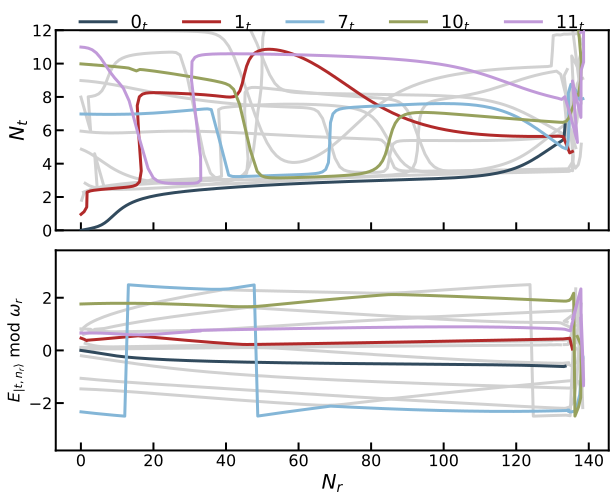

In [20]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt

# ---------------- parameters ----------------
EC, EJ, ng = 0.2, 20.0, 0.25
wr, g = 5.0, 0.1
ncut = 100
Nt, Nr = 14, 140   # start smaller; increase later if needed

# ---------------- transmon in charge basis ----------------
nvals = np.arange(-ncut, ncut + 1)
dim_c = len(nvals)

n_op = qt.Qobj(np.diag(nvals))
shift = qt.Qobj(np.diag(np.ones(dim_c - 1), 1))
cos_phi = (shift + shift.dag()) / 2
Ht_charge = 4 * EC * (n_op - ng * qt.qeye(dim_c))**2 - EJ * cos_phi

Et_all, t_states_all = Ht_charge.eigenstates()
Et = np.array(Et_all[:Nt])
t_states = t_states_all[:Nt]

n_t = qt.Qobj(np.array([
    [t_states[i].overlap(n_op * t_states[j]) for j in range(Nt)]
    for i in range(Nt)
], dtype=complex))

Ht = qt.Qobj(np.diag(Et))

# ---------------- resonator + full Hamiltonian ----------------
a = qt.destroy(Nr)
num_r = a.dag() * a
I_t, I_r = qt.qeye(Nt), qt.qeye(Nr)

a = qt.destroy(Nr)
num_r = a.dag() * a

# oscillator charge operator for l_osc = 1
# this is the thing meant to match scqubits' res.n_operator
n_r = 1j * (a.dag() - a) / np.sqrt(2)

H = qt.tensor(Ht, I_r) + qt.tensor(I_t, wr * num_r) + g * qt.tensor(n_t, n_r)

evals, evecs = H.eigenstates()

# ---------------- bare basis + excitation ops ----------------
bare = [[qt.tensor(qt.basis(Nt, t), qt.basis(Nr, r)) for r in range(Nr)] for t in range(Nt)]

Aup = qt.tensor(I_t, a.dag())
Tplus = qt.tensor(qt.Qobj(np.diag(np.ones(Nt - 1), -1)), I_r)   # sum_t |t><t-1| ⊗ I

def best_unlabeled(target, unlabeled):
    overlaps = [abs(evecs[k].overlap(target))**2 for k in unlabeled]
    return list(unlabeled)[int(np.argmax(overlaps))]

# ---------------- branch analysis ----------------
unlabeled = list(range(Nt * Nr))
lookup = -np.ones((Nt, Nr), dtype=int)

def pick(target):
    global unlabeled
    overlaps = np.array([abs(evecs[k].overlap(target))**2 for k in unlabeled])
    j = int(np.argmax(overlaps))
    k = unlabeled[j]
    unlabeled.pop(j)
    return k

# seed |0,0>
lookup[0, 0] = pick(bare[0][0])

# finish branch t=0 by repeated a†
for r in range(1, Nr):
    lookup[0, r] = pick(Aup * evecs[lookup[0, r - 1]])

# higher transmon branches
for t in range(1, Nt):
    lookup[t, 0] = pick(Tplus * evecs[lookup[t - 1, 0]])
    for r in range(1, Nr):
        lookup[t, r] = pick(Aup * evecs[lookup[t, r - 1]])

# ---------------- observables for Fig. 2 ----------------
Nt_op = qt.tensor(qt.Qobj(np.diag(np.arange(Nt))), I_r)
Nr_op = qt.tensor(I_t, num_r)

Nt_avg = np.array([qt.expect(Nt_op, psi).real for psi in evecs])
Nr_avg = np.array([qt.expect(Nr_op, psi).real for psi in evecs])
Emod = ((np.array(evals) - evals[0] + wr / 2) % wr) - wr / 2

# ---------------- plot ----------------
hi = {0:"#314a5d", 1:"#b12a2a", 7:"#84b6d7", 10:"#97a15d", 11:"#c19ad9"}

fig, ax = plt.subplots(2, 1, figsize=(9, 7), sharex=True, dpi=160)

for t in range(Nt):
    idx = lookup[t]
    style = dict(color=hi[t], lw=3, zorder=3, label=fr"${t}_t$") if t in hi else dict(color="0.82", lw=3, zorder=1)
    ax[0].plot(Nr_avg[idx], Nt_avg[idx], **style)
    ax[1].plot(Nr_avg[idx], Emod[idx], **style)

for axy in ax:
    axy.tick_params(direction="in", length=8, width=2, labelsize=16)
    for s in axy.spines.values():
        s.set_linewidth(2)

ax[0].set_ylabel(r"$N_t$", fontsize=20)
ax[1].set_ylabel(r"$E_{|t,n_r\rangle}\ \mathrm{mod}\ \omega_r$", fontsize=16)
ax[1].set_xlabel(r"$N_r$", fontsize=20)
ax[0].set_ylim(0, 12)
ax[1].set_ylim(-3.8, 3.8)
ax[0].legend(ncol=5, frameon=False, loc="upper center", bbox_to_anchor=(0.5, 1.16), fontsize=18)

plt.tight_layout()
plt.show()

#### Semi-Classical

#### Fully Classical